<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/ANN_resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv')
df.head(20)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
5,6,Samantha Santos,"Cybersecurity, Networking, Linux, Ethical Hacking",10,B.Tech,Google ML,Cybersecurity Analyst,Hire,47957,5,100
6,7,Tony Smith,"Networking, Cybersecurity, Ethical Hacking",4,M.Tech,AWS Certified,Cybersecurity Analyst,Hire,66208,9,100
7,8,Anthony Harrison,"TensorFlow, Pytorch, NLP",3,M.Tech,AWS Certified,AI Researcher,Hire,103006,7,90
8,9,Nancy Jenkins,"Networking, Ethical Hacking",7,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,92270,3,100
9,10,Courtney Gibson,"Python, TensorFlow, Pytorch, NLP",0,M.Tech,AWS Certified,AI Researcher,Reject,60579,1,35


In [6]:
df.shape

(1000, 11)

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [8]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [9]:
df['Certifications'].fillna('No Certification', inplace=True)
df['Certifications'].isnull().sum()

/tmp/ipykernel_4335/67032770.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Certifications'].fillna('No Certification', inplace=True)


np.int64(0)

In [10]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [11]:
df[df.isnull().any(axis=1)]

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)


In [12]:
print(df['Job Role'].unique())

['AI Researcher' 'Data Scientist' 'Cybersecurity Analyst'
 'Software Engineer']


In [13]:
print(df['Education'].unique())

['B.Sc' 'MBA' 'B.Tech' 'PhD' 'M.Tech']


In [14]:
df['Recruiter_Decision_Mapped'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
display(df.head())

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Recruiter_Decision_Mapped
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100,1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,1
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100,1


In [15]:
X=df.iloc[:,:-1]
print(X)

     Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...                 ...   
995              Cybe

In [16]:
Y=df.iloc[:,-1]
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    1
998    1
999    1
Name: Recruiter_Decision_Mapped, Length: 1000, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

In [19]:
X_train.shape, X_test.shape

((700, 11), (300, 11))

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']

X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

In [22]:
X_train , X_test

(     Resume_ID                Name                                   Skills  \
 541        542       Angie Roberts  Deep Learning, Python, Machine Learning   
 440        441            Zoe King  Deep Learning, Python, Machine Learning   
 482        483       Jodi Franklin                         React, C++, Java   
 422        423       Zachary Cohen         NLP, TensorFlow, Pytorch, Python   
 778        779       Matthew Smith  Deep Learning, Machine Learning, Python   
 ..         ...                 ...                                      ...   
 106        107    David Richardson                  NLP, Python, TensorFlow   
 270        271           Amy Poole            Machine Learning, SQL, Python   
 860        861        Karen Acosta                          Pytorch, Python   
 435        436       Maria Manning               Python, Deep Learning, SQL   
 102        103  Jonathan Hernandez              Ethical Hacking, Networking   
 
      Experience (Years) Education    

In [23]:
import tensorflow as tf

In [24]:
ann = tf.keras.models.Sequential()

In [25]:
ann.add(tf.keras.layers.Dense(units=10, activation='relu'))

In [26]:
ann.add(tf.keras.layers.Dense(units=9, activation='relu'))

In [27]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

In [32]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [33]:
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

In [38]:
# Define columns for processing
cols_to_drop_from_X = ['Resume_ID', 'Name', 'Recruiter Decision']
categorical_cols_to_encode = ['Skills', 'Education', 'Certifications', 'Job Role']
# numerical_cols is already defined in a previous cell as ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']

# Prepare X_train and X_test by dropping irrelevant columns
X_train_features = X_train.drop(columns=cols_to_drop_from_X)
X_test_features = X_test.drop(columns=cols_to_drop_from_X)

# One-hot encode categorical features
X_train_categorical_encoded = pd.get_dummies(X_train_features[categorical_cols_to_encode], drop_first=True).astype(int)
X_test_categorical_encoded = pd.get_dummies(X_test_features[categorical_cols_to_encode], drop_first=True).astype(int)

# Align columns after one-hot encoding to ensure consistency between train and test sets
all_categorical_cols = X_train_categorical_encoded.columns.union(X_test_categorical_encoded.columns)

X_train_categorical_encoded = X_train_categorical_encoded.reindex(columns=all_categorical_cols, fill_value=0)
X_test_categorical_encoded = X_test_categorical_encoded.reindex(columns=all_categorical_cols, fill_value=0)

# Convert X_train_scaled and X_test_scaled (numpy arrays) back to DataFrames for concatenation
# Ensure indices match for correct concatenation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train_features.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test_features.index)

# Concatenate scaled numerical features with one-hot encoded categorical features
X_train_final = pd.concat([X_train_scaled_df, X_train_categorical_encoded], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_categorical_encoded], axis=1)

# Convert the final processed dataframes to numpy arrays for TensorFlow model input
X_train_final = X_train_final.to_numpy().astype(float)
X_test_final = X_test_final.to_numpy().astype(float)

# Fit the ANN model with the fully processed numerical data
ann.fit(X_train_final, Y_train, batch_size=32, epochs=100)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2229 - loss: 0.7539 
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6314 - loss: 0.6894 
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8671 - loss: 0.6690 
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9071 - loss: 0.6483 
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9229 - loss: 0.6135 
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9500 - loss: 0.5628
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9714 - loss: 0.4864 
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9757 - loss: 0.3842 
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9786 - loss: 0.2721 
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9843 - loss: 0.1838 
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9857 - loss: 0.1290 
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

In [39]:
  Y_pred = ann.predict(X_test_final)
  Y_pred = (Y_pred > 0.5)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(Y_test, Y_pred)
print(cm)
accuracy_score(Y_test, Y_pred)

[[ 61   3]
 [  2 234]]


0.9833333333333333

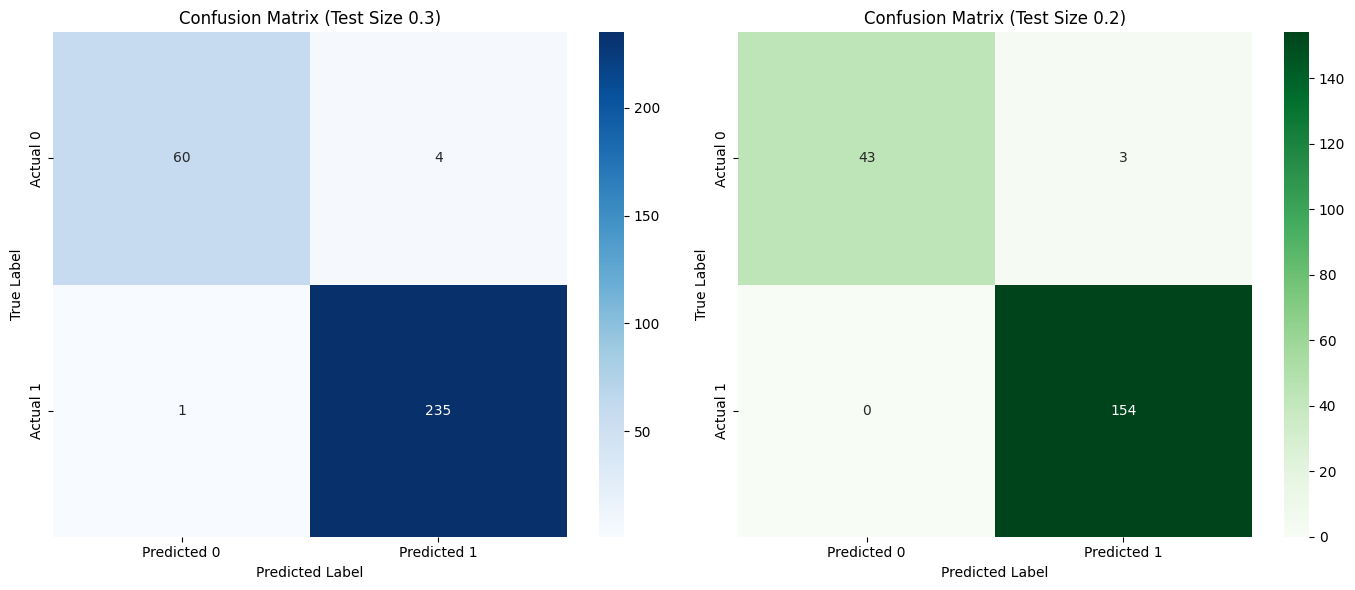

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Define numerical columns
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_numerical = df[numerical_cols]
Y_true_labels = df['Recruiter_Decision_Mapped']

# --- Confusion Matrix for test_size = 0.3 ---
X_train_03, X_test_03, Y_train_03, Y_test_03 = train_test_split(X_numerical, Y_true_labels, train_size=0.7, test_size=0.3, random_state=42)

liner_svc_03 = SVC(kernel='linear', C=100.0)
liner_svc_03.fit(X_train_03, Y_train_03)
Y_pred_03 = liner_svc_03.predict(X_test_03)
cm_03 = confusion_matrix(Y_test_03, Y_pred_03)


# --- Confusion Matrix for test_size = 0.2 ---
X_train_02, X_test_02, Y_train_02, Y_test_02 = train_test_split(X_numerical, Y_true_labels, train_size=0.8, test_size=0.2, random_state=42)

liner_svc_02 = SVC(kernel='linear', C=100.0)
liner_svc_02.fit(X_train_02, Y_train_02)
Y_pred_02 = liner_svc_02.predict(X_test_02)
cm_02 = confusion_matrix(Y_test_02, Y_pred_02)


# --- Plotting the Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_03, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Confusion Matrix (Test Size 0.3)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_02, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title('Confusion Matrix (Test Size 0.2)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()